# WAVEGUISE applied to AWE data
WAVEGUISE is applied to an AWE swath over Crozet island in the south Indian ocean. Orbit 3175

In [23]:
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('../scripts')
import utils_2d as two

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import copy
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib import cm
"""
import os
from matplotlib.colors import BoundaryNorm
from numpy.linalg import norm
from scipy.stats import circmean
"""
plt.style.use("../latex_default.mplstyle")

Text(0.5, 0, 'Z')

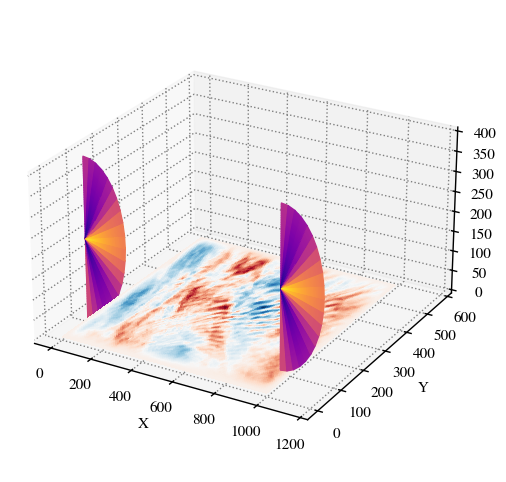

In [65]:
# -------------------------
# UNTERE EBENE (normal 2D)
# -------------------------
Xb, Yb = np.meshgrid(x, y)
Z_bottom = signal

# -------------------------
# OBERE EBENE (polar)
# -------------------------
nr, ntheta = js, jt
r = np.linspace(0, 200, nr)
theta = np.linspace(-np.pi/2, np.pi/2, ntheta)
R, TH = np.meshgrid(r, theta)

# Beispiel-POLAR-DATEN
Z_polar = np.cos(3*TH) * np.exp(-R/200)

# Polar → kartesisch
Xp = R * np.cos(TH)
Zp = R * np.sin(TH)

# -------------------------
# Farben
# -------------------------
norm = plt.Normalize(vmin=Z_bottom.min(),vmax=Z_bottom.max())
colors_bottom = cm.RdBu_r(norm(Z_bottom))
norm = plt.Normalize(vmin=Z_polar.min(),vmax=Z_polar.max())
colors_polar  = cm.plasma(norm(Z_polar))

# -------------------------
# 3D-PLOT
# -------------------------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

# Boden
surf_bottom = ax.plot_surface(
    Xb, Yb, np.zeros_like(Xb),
    facecolors=colors_bottom,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False)

# Polar-Ebene 
surf_polar = ax.plot_surface(
    Xp+950, np.zeros_like(Zp)+100, Zp+201,
    facecolors=colors_polar,
    rstride=1, cstride=1,
    shade=False)

surf_polar = ax.plot_surface(
    Xp, np.zeros_like(Zp)+100, Zp+201,
    facecolors=colors_polar,
    rstride=1, cstride=1,
    shade=False)

"""
for r0 in [0.25, 0.5, 0.75]:
    ax.plot(
        r0*np.cos(theta),
        r0*np.sin(theta),
        z1,
        color="k",
        lw=0.5,
        #alpha=0.4
    )
"""
surf_bottom.set_zsort('min')
surf_polar.set_zsort('max')

ax.view_init(elev=25, azim=-60)
ax.set_box_aspect((1, 1, 0.6))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")



In [66]:
Xp.shape

(21, 49)

In [48]:
import numpy as np
import plotly.graph_objects as go

# -------------------------
# UNTERE EBENE (normal 2D)
# -------------------------
Xb, Yb = np.meshgrid(x, y)

Z_bottom = signal#np.sin(2*np.pi*Xb/600) * np.cos(2*np.pi*Yb/600)  # <- hier: signal
Zb_plane = np.zeros_like(Z_bottom)

# -------------------------
# OBERE EBENE (polar)
# -------------------------
nr, ntheta = js, jt
r = np.linspace(0, 200, nr)
theta = np.linspace(-np.pi/2, np.pi/2, ntheta)
R, TH = np.meshgrid(r, theta)

Z_polar = np.cos(3*TH) * np.exp(-R/200)

# Polar -> kartesisch (wie bei dir: X und "Z" aus Polar)
Xp = R * np.cos(TH)
Zp = R * np.sin(TH)

# Positionierung im 3D-Raum: "Vorhang" bei y = y_wall, und zusätzlich z_offset
y_wall  = 200.0
z_offset = 200.0

Yp = y_wall * np.ones_like(Xp)
Zp3 = Zp + z_offset

# -------------------------
# Plotly Surfaces
# -------------------------
fig = go.Figure()

# Boden
fig.add_trace(go.Surface(
    x=Xb, y=Yb, z=Zb_plane,
    surfacecolor=Z_bottom,
    colorscale="RdBu",
    reversescale=True,   # entspricht ungefähr RdBu_r
    showscale=True,
    colorbar=dict(title="bottom")
))

# Polar-"Vorhang" (schwebend / vertikal)
fig.add_trace(go.Surface(
    x=Xp, y=Yp, z=Zp3,
    surfacecolor=Z_polar,
    colorscale="Plasma",
    showscale=True,
    colorbar=dict(title="polar")
))

# -------------------------
# Layout / Kamera
# -------------------------
fig.update_layout(
    width=900, height=700,
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectratio=dict(x=1, y=1, z=0.6),
        camera=dict(
            eye=dict(x=1.6, y=-1.8, z=1.0)  # grob ähnlich zu elev/azim
        )
    )
)

fig.show()


ModuleNotFoundError: No module named 'plotly'

In [21]:
data_path = '../data/awe_l3c_q20_2024165T2120_03175_v01.nc'
ds = xr.open_dataset(data_path)

Text(0.5, 1.0, 'Orbit 03175')

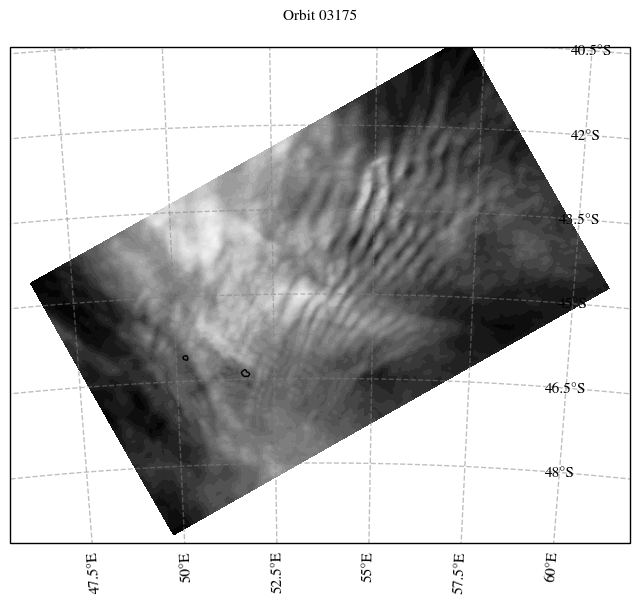

In [3]:
lon = ds['Longitude'].isel(time=0,x_along_track=slice(3000,3500),y_cross_track=slice(60,350))
lat = ds['Latitude'].isel(time=0,x_along_track=slice(3000,3500),y_cross_track=slice(60,350))
z   = ds['Radiance'].isel(time=0,x_along_track=slice(3000,3500),y_cross_track=slice(60,350))

lonW, lonE = lon.min(), lon.max()
latN, latS = lat.max(), lat.min()
clon, clat = (lonW+lonE)/2, (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon.values, central_latitude=clat.values)

# Define figure size
fig_width = 8
fig_height = 8

# Create the 3D plot
letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
Titel='Orbit 03175'

fig=plt.figure(figsize=(fig_width,fig_height))
ax = fig.add_subplot(projection=projStr)

ax.set_extent([lonW, lonE, latS, latN], ccrs.PlateCarree())
ax.coastlines()
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.right_labels = True  # Hide labels on the right side
gridlines.left_labels = True  # Hide labels on the right side
gridlines.top_labels = False    # Hide labels on the top
gridlines.bottom_labels = True    # Hide labels on the top
    
BI_lev = np.linspace(10,40,31)
contour = ax.contourf(lon,lat,z,cmap='Greys_r',transform=ccrs.PlateCarree(),zorder=1,levels=BI_lev,extend='both')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(Titel,pad=20)

#plt.savefig('./AWE_plots/Crozet_03175.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [22]:
orig =ds["Radiance"].isel(time=0,x_along_track=slice(3000,3500),y_cross_track=slice(60,350))
orig-=orig.mean()
BI_high, BI_low = two.BG_removal(orig.values,max_order=1)
dx, dy = 2000, 2000
nx, ny = orig['x_along_track'].size, orig['y_cross_track'].size
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
x = np.linspace(0,(nx-1)*dx,nx)*1e-3
print(nx, ny)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

500 290


In [32]:
s0 = 2 * dx
dj = 1 / 8
js=int(1/dj*np.log2(min([nx,ny])/2*dx/s0))
jt = 21
print(js, jt)

result = transform.decompose2d(signal,dx,dy,s0,dj,js,jt,aspect=1,
                               nxpad=None,nypad=None,opts={'param': 2*np.pi},
                               mode="scaled",dtype=np.complex128)

print(result["period"][0],result["period"][-1])

49 21
4000.0 256000.0


In [10]:
cwt_copy   = copy.deepcopy(result)
WPS        = np.abs(cwt_copy['decomposition'])**2
median_WPS = np.median(WPS,axis=(1,2,3))
sMAD_WPS   = 1.4826*stats.median_abs_deviation(WPS,axis=(1,2,3))
WPS_scaled = (WPS-median_WPS[:,np.newaxis,np.newaxis,np.newaxis])/sMAD_WPS[:,np.newaxis,np.newaxis,np.newaxis]
mask       = WPS_scaled < 10
cwt_copy['decomposition'][mask]=0

In [11]:
wavy_stuff  = transform.reconstruct2d(cwt_copy)
noisy_stuff = signal - wavy_stuff 

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/scratch-local/slurm-job-tmp-12238122/ipykernel_1798/4024040407.py:19: SyntaxWarning: invalid escape sequence '\s'
  ax.text(0.12,0.95, f"$\sigma_{{noise}} = {np.std(noisy_stuff):.2f}$", verticalalignment='center', horizontalalignment='center', weight = 'bold', bbox=titlebox, transform=ax.transAxes)


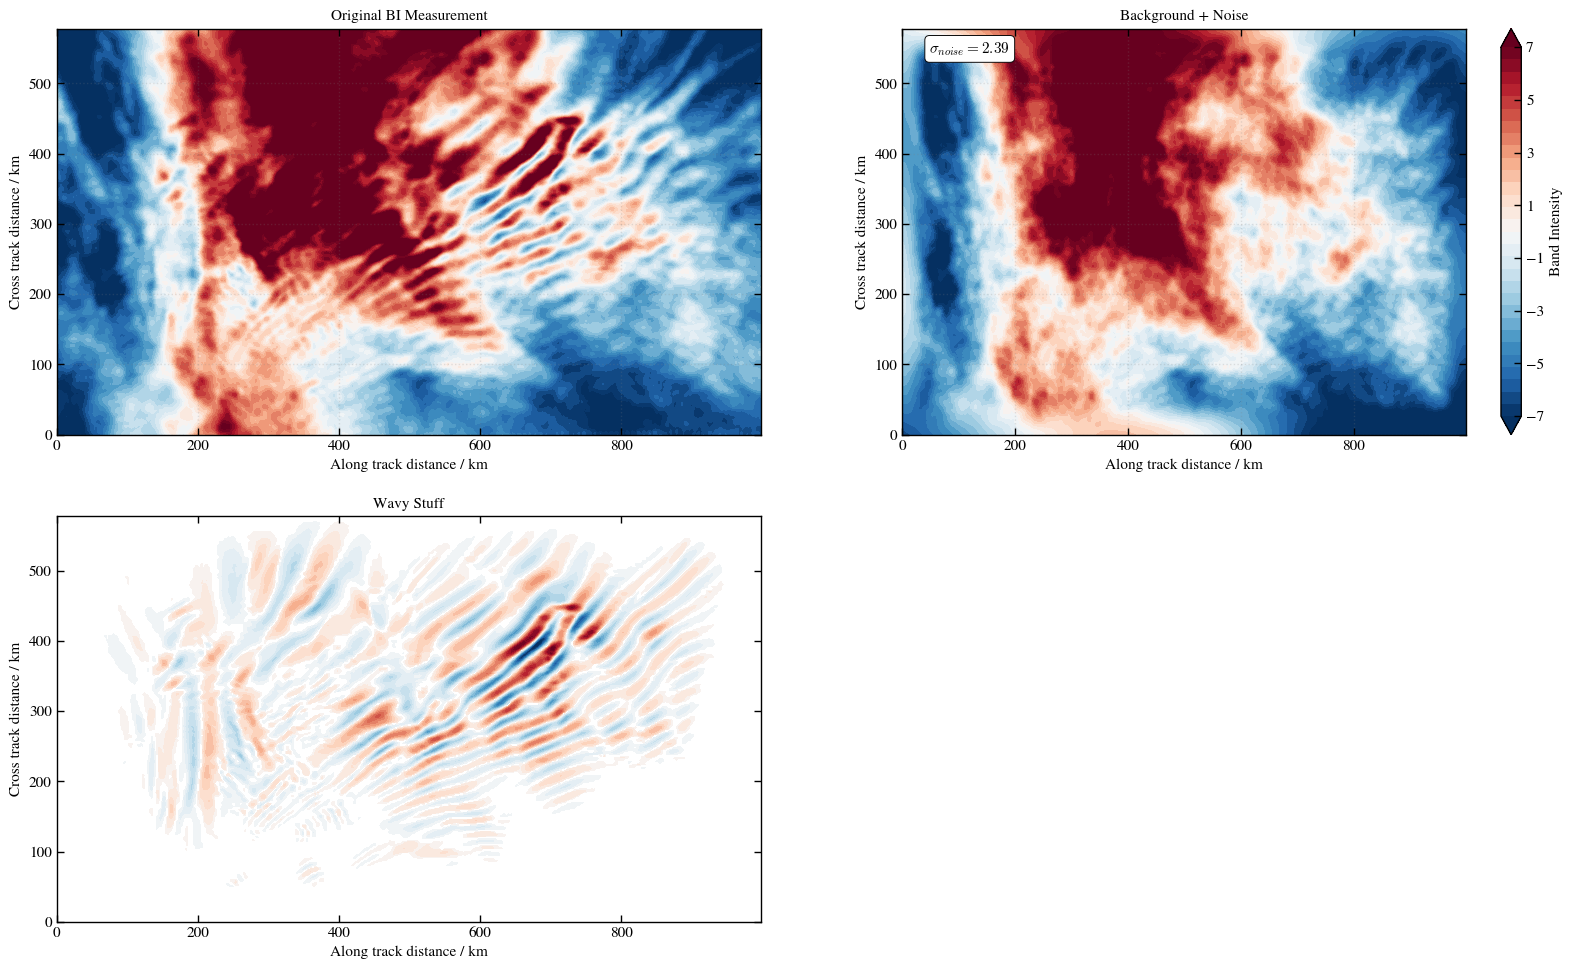

In [14]:
titlebox = {"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}

rad_lev   = np.linspace(-7,7,31)
lev_ticks = [-7,-5,-3,-1,1,3,5,7]

fig=plt.figure(figsize=(nx/25,ny/25))
ax=fig.add_subplot(221)
ax.contourf(x,y,orig,levels=rad_lev,extend="both",cmap="RdBu_r")
ax.set_title('Original BI Measurement')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")

ax=fig.add_subplot(222)
plot_BG = ax.contourf(x,y,BI_low+noisy_stuff,levels=rad_lev,extend="both",cmap="RdBu_r")
ax.set_title('Background + Noise')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")
cbar = fig.colorbar(plot_BG,label="Band Intensity",ticks=lev_ticks)
ax.text(0.12,0.95, f"$\sigma_{{noise}} = {np.std(noisy_stuff):.2f}$", verticalalignment='center', horizontalalignment='center', weight = 'bold', bbox=titlebox, transform=ax.transAxes)

ax=fig.add_subplot(223)
masked = np.ma.masked_inside(wavy_stuff, -0.2, 0.2)  
norm = mcolors.TwoSlopeNorm(vmin=rad_lev[0], vcenter=0.0, vmax=rad_lev[-1])
ax.contourf(x,y,masked,levels=rad_lev,cmap="RdBu_r",norm=norm,extend='both')
ax.set_title('Wavy Stuff')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")
ax.grid(which='both')

#plt.savefig('./AWE_plots/AWE_preparation_03175.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
/scratch-local/slurm-job-tmp-12238122/ipykernel_1798/3009751874.py:20: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Orientation / $\circ$')


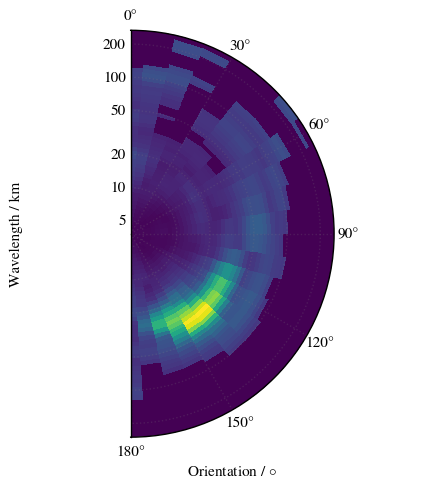

In [16]:
WPS=np.abs(cwt_copy['decomposition'])
th=result['theta']
th2 = np.append(th,th+np.pi)
pe=result['period']

sel_WPS = np.max(WPS,axis=(2,3))
sel_WPS_pad = np.pad(sel_WPS, ((0,0),(0,sel_WPS.shape[1])), mode="wrap")

fig = plt.figure(figsize=(0.25*len(result['theta']),0.25*len(result['scale'])))
ax=fig.add_subplot(projection='polar')

pcm = ax.pcolormesh(th2,pe*1e-3,sel_WPS_pad,shading='auto')#vmin=spec_lev.min(), vmax=spec_lev.max()
ax.set_yscale('log')
ax.set_theta_zero_location("N")  # theta=0 at the top
ax.set_theta_direction(-1)
ax.set_xlim([0,np.pi])

ax.set_ylabel('Wavelength / km')
ax.set_xlabel('Orientation / $\circ$')
ax.set_yticks(ticks=[5,10,20,50,100,200],labels=[5,10,20,50,100,200])

#plt.savefig('./AWE_plots/mean_spectrum_03175.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")